In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df1 = pd.read_csv("Code Descriptions.csv")
df2 = pd.read_csv("TTC Subway Delay Data since 2025.csv")

In [8]:
df1.head(3)

,_id,CODE,DESCRIPTION
0,1,EUAC,AIR CONDITIONING
1,2,EUAL,ALTERNATING CURRENT
2,3,EUATC,ATC RC&S EQUIPMENT


In [9]:
df2.head(3)

,_id,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle
0,1,2025-01-01,2:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227
1,2,2025-01-01,2:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0
2,3,2025-01-01,2:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0


In [10]:
df = df2.merge(df1, left_on = 'Code', right_on = 'CODE', how = 'left')


In [11]:
df.head(5)

,_id_x,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle,_id_y,CODE,DESCRIPTION
0,1,2025-01-01,2:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227,59.0,MUSAN,UNSANITARY VEHICLE
1,2,2025-01-01,2:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0,46.0,MUIRS,INJURED/ILL CUSTOMER IN STATION â MEDICAL AI...
2,3,2025-01-01,2:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0,75.0,PUMST,ANY STAIRWAY INCIDENT â TRANSPORTED OR MEDIC...
3,4,2025-01-01,2:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293,23.0,EUSC,SPEED CONTROL EQUIPMENT
4,5,2025-01-01,2:58,Wednesday,COXWELL STATION,SUAE,0,0,NaN,BD,0,110.0,SUAE,ASSAULT / EMPLOYEE INVOLVED


In [12]:
df.isnull().sum()

_id_x             0
Date              0
Time              0
Day               0
Station           0
Code              0
Min Delay         0
Min Gap           0
Bound          9462
Line             67
Vehicle           0
_id_y           132
CODE            132
DESCRIPTION     132
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25713 entries, 0 to 25712
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   _id_x        25713 non-null  int64  
 1   Date         25713 non-null  object 
 2   Time         25713 non-null  object 
 3   Day          25713 non-null  object 
 4   Station      25713 non-null  object 
 5   Code         25713 non-null  object 
 6   Min Delay    25713 non-null  int64  
 7   Min Gap      25713 non-null  int64  
 8   Bound        16251 non-null  object 
 9   Line         25646 non-null  object 
 10  Vehicle      25713 non-null  int64  
 11  _id_y        25581 non-null  float64
 12  CODE         25581 non-null  object 
 13  DESCRIPTION  25581 non-null  object 
dtypes: float64(1), int64(4), object(9)
memory usage: 2.7+ MB


In [14]:
df.describe(include='all')

,_id_x,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle,_id_y,CODE,DESCRIPTION
count,25713.000000,25713,25713,25713,25713,25713,25713.000000,25713.000000,16251,25646,25713.000000,25581.000000,25581,25581
unique,NaN,365,1426,7,475,131,NaN,NaN,5,18,NaN,NaN,128,128
top,NaN,2025-07-30,22:00,Wednesday,KENNEDY BD STATION,SUDP,NaN,NaN,S,YU,NaN,NaN,SUDP,DISORDERLY PATRON
freq,NaN,144,373,4035,991,2945,NaN,NaN,4357,13079,NaN,NaN,2945,2945
mean,12857.000000,NaN,NaN,NaN,NaN,NaN,2.751682,3.908645,NaN,NaN,3201.175242,78.693405,NaN,NaN
std,7422.848072,NaN,NaN,NaN,NaN,NaN,11.101464,11.742261,NaN,NaN,2736.543963,35.612582,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,1.000000,NaN,NaN
25%,6429.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,47.000000,NaN,NaN
50%,12857.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,5110.000000,73.000000,NaN,NaN
75%,19285.000000,NaN,NaN,NaN,NaN,NaN,4.000000,7.000000,NaN,NaN,5551.000000,114.000000,NaN,NaN


In [15]:
df.nunique()

_id_x          25713
Date             365
Time            1426
Day                7
Station          475
Code             131
Min Delay        105
Min Gap          113
Bound              5
Line              18
Vehicle          742
_id_y            128
CODE             128
DESCRIPTION      128
dtype: int64

#  Cleaning dataset for analyzing

In [16]:
df.columns = (df.columns.str.lower()
                        .str.strip())

In [17]:
df.columns

Index(['_id_x', 'date', 'time', 'day', 'station', 'code', 'min delay',
       'min gap', 'bound', 'line', 'vehicle', '_id_y', 'code', 'description'],
      dtype='object')

In [18]:
df_copy = df.copy()

In [19]:
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"],
                                format="%Y-%m-%d %H:%M", errors="coerce")


In [20]:
df["min delay"] = pd.to_numeric(df["min delay"], errors="coerce")
df["min gap"]   = pd.to_numeric(df["min gap"], errors="coerce")
df["vehicle"]   = pd.to_numeric(df["vehicle"], errors="coerce")
df["id x"]     = pd.to_numeric(df["_id_x"], errors="coerce")
df["id y"]     = pd.to_numeric(df["_id_y"], errors="coerce")

In [21]:
cat_cols = ["day", "station", "code", "bound", "line", "code"]
for c in cat_cols:
    df[c] = df[c].astype("category")

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25713 entries, 0 to 25712
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   _id_x        25713 non-null  int64         
 1   date         25713 non-null  object        
 2   time         25713 non-null  object        
 3   day          25713 non-null  category      
 4   station      25713 non-null  category      
 5   code         25713 non-null  object        
 6   min delay    25713 non-null  int64         
 7   min gap      25713 non-null  int64         
 8   bound        16251 non-null  category      
 9   line         25646 non-null  category      
 10  vehicle      25713 non-null  int64         
 11  _id_y        25581 non-null  float64       
 12  code         25581 non-null  object        
 13  description  25581 non-null  object        
 14  datetime     25713 non-null  datetime64[ns]
 15  id x         25713 non-null  int64         
 16  id y

In [23]:
df["description"] = df["description"].str.replace("â", "-", regex=False)

#  Handling null Values

In [24]:
for c in ["bound", "line", "code", "description"]:
    if pd.api.types.is_categorical_dtype(df[c]):
     
        df[c] = df[c].cat.add_categories("Unknown")
      
        df[c] = df[c].fillna("Unknown")
    else:
       
        df[c] = df[c].fillna("Unknown")


In [25]:
for c in ["bound","line", "code", "description"]:
    df[c] = df[c].fillna("Unknown")

In [26]:
df.isnull().sum()

_id_x            0
date             0
time             0
day              0
station          0
code             0
min delay        0
min gap          0
bound            0
line             0
vehicle          0
_id_y          132
code             0
description      0
datetime         0
id x             0
id y           132
dtype: int64

#  _id_y looks like an ID from the merged table; NaN just means "no matching record". Keep it as NaN or set to -1.

In [27]:
df["id y"] = df["id y"].fillna(-1).astype(int)


#    Feature engieering for analysis

In [28]:
df["year"]  = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["hour"]  = df["datetime"].dt.hour


In [29]:
df["isdelayed"] = (df["min delay"] > 0).astype(int)

In [30]:
bins = [-0.1, 0, 5, 10, 20, np.inf]
labels = ["0", "1-5", "6-10", "11-20", "20+"]
df["delaybucket"] = pd.cut(df["min delay"], bins=bins, labels=labels)

In [31]:
df.head(3)

,_id_x,date,time,day,station,code,min delay,min gap,bound,line,...,code,description,datetime,id x,id y,year,month,hour,isdelayed,delaybucket
0,1,2025-01-01,2:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,...,MUSAN,UNSANITARY VEHICLE,2025-01-01 02:10:00,1,59,2025,1,2,1,1-5
1,2,2025-01-01,2:30,Wednesday,DUNDAS STATION,MUIRS,0,0,Unknown,YU,...,MUIRS,INJURED/ILL CUSTOMER IN STATION - MEDICAL AID ...,2025-01-01 02:30:00,2,46,2025,1,2,0,0
2,3,2025-01-01,2:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,...,PUMST,ANY STAIRWAY INCIDENT - TRANSPORTED OR MEDICAL...,2025-01-01 02:32:00,3,75,2025,1,2,0,0


In [32]:
df['description'] = (
    df['description']
    .str.encode('latin1')
    .str.decode('utf-8', errors='ignore')
    .str.strip()
)

In [33]:
df.head()

,_id_x,date,time,day,station,code,min delay,min gap,bound,line,...,code,description,datetime,id x,id y,year,month,hour,isdelayed,delaybucket
0,1,2025-01-01,2:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,...,MUSAN,UNSANITARY VEHICLE,2025-01-01 02:10:00,1,59,2025,1,2,1,1-5
1,2,2025-01-01,2:30,Wednesday,DUNDAS STATION,MUIRS,0,0,Unknown,YU,...,MUIRS,INJURED/ILL CUSTOMER IN STATION - MEDICAL AID ...,2025-01-01 02:30:00,2,46,2025,1,2,0,0
2,3,2025-01-01,2:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,...,PUMST,ANY STAIRWAY INCIDENT - TRANSPORTED OR MEDICAL...,2025-01-01 02:32:00,3,75,2025,1,2,0,0
3,4,2025-01-01,2:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,...,EUSC,SPEED CONTROL EQUIPMENT,2025-01-01 02:58:00,4,23,2025,1,2,0,0
4,5,2025-01-01,2:58,Wednesday,COXWELL STATION,SUAE,0,0,Unknown,BD,...,SUAE,ASSAULT / EMPLOYEE INVOLVED,2025-01-01 02:58:00,5,110,2025,1,2,0,0


#  Checking for outliers in Min Delay and max Delay columns

In [34]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

In [35]:
for col in ["min delay", "min gap"]:
    lower, upper = iqr_bounds(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")


min delay: 1403 outliers
min gap: 920 outliers


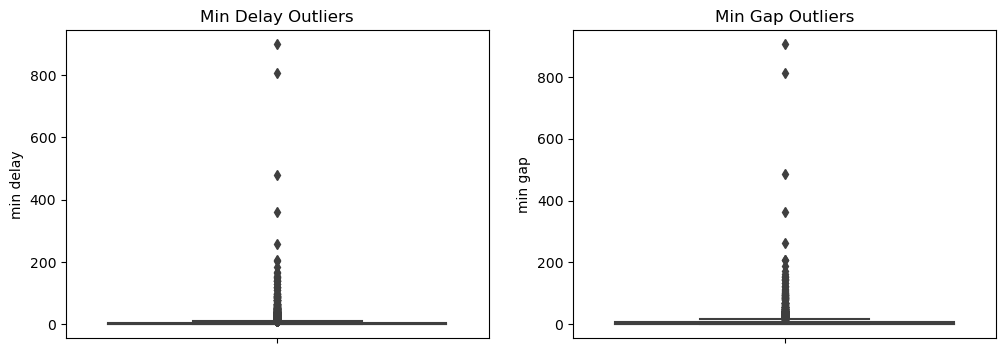

In [36]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["min delay"], ax=axes[0])
axes[0].set_title("Min Delay Outliers")

sns.boxplot(y=df["min gap"], ax=axes[1])
axes[1].set_title("Min Gap Outliers")

plt.show()


## There are mant outliers in both columns Min Delay and Min Gap so rather than dropping them or clipping them I will create different categories to handlem them.

In [37]:
def delay_bucket(x):
    if x == 0:
        return "No Delay"
    elif x <= 5:
        return "Minor (1–5 min)"
    elif x <= 15:
        return "Moderate (6–15 min)"
    elif x <= 30:
        return "Major (16–30 min)"
    else:
        return "Severe (30+ min)"

df["delay category"] = df["min delay"].apply(delay_bucket)


In [38]:
def gap_bucket(x):
    if x == 0:
        return "No Gap Issue"
    elif x <= 5:
        return "Minor Gap (1–5 min)"
    elif x <= 15:
        return "Moderate Gap (6–15 min)"
    elif x <= 30:
        return "Major Gap (16–30 min)"
    else:
        return "Severe Gap (30+ min)"

df["gap category"] = df["min gap"].apply(gap_bucket)


In [39]:
df.head(3)

,_id_x,date,time,day,station,code,min delay,min gap,bound,line,...,datetime,id x,id y,year,month,hour,isdelayed,delaybucket,delay category,gap category
0,1,2025-01-01,2:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,...,2025-01-01 02:10:00,1,59,2025,1,2,1,1-5,Minor (1–5 min),Moderate Gap (6–15 min)
1,2,2025-01-01,2:30,Wednesday,DUNDAS STATION,MUIRS,0,0,Unknown,YU,...,2025-01-01 02:30:00,2,46,2025,1,2,0,0,No Delay,No Gap Issue
2,3,2025-01-01,2:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,...,2025-01-01 02:32:00,3,75,2025,1,2,0,0,No Delay,No Gap Issue


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25713 entries, 0 to 25712
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   _id_x           25713 non-null  int64         
 1   date            25713 non-null  object        
 2   time            25713 non-null  object        
 3   day             25713 non-null  category      
 4   station         25713 non-null  category      
 5   code            25713 non-null  object        
 6   min delay       25713 non-null  int64         
 7   min gap         25713 non-null  int64         
 8   bound           25713 non-null  category      
 9   line            25713 non-null  category      
 10  vehicle         25713 non-null  int64         
 11  _id_y           25581 non-null  float64       
 12  code            25713 non-null  object        
 13  description     25713 non-null  object        
 14  datetime        25713 non-null  datetime64[ns]
 15  id

#  Rename columns 

In [41]:
df = df.rename(columns={
    "id x": "incident_id",
    "id y": "reason_id",
    "min delay": "min_delay",
    "min gap": "min_gap",
    "delay category": "delay_category",
    "gap category": "gap_category"
})

In [42]:
df.columns

Index(['_id_x', 'date', 'time', 'day', 'station', 'code', 'min_delay',
       'min_gap', 'bound', 'line', 'vehicle', '_id_y', 'code', 'description',
       'datetime', 'incident_id', 'reason_id', 'year', 'month', 'hour',
       'isdelayed', 'delaybucket', 'delay_category', 'gap_category'],
      dtype='object')

In [43]:
df.head()

,_id_x,date,time,day,station,code,min_delay,min_gap,bound,line,...,datetime,incident_id,reason_id,year,month,hour,isdelayed,delaybucket,delay_category,gap_category
0,1,2025-01-01,2:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,...,2025-01-01 02:10:00,1,59,2025,1,2,1,1-5,Minor (1–5 min),Moderate Gap (6–15 min)
1,2,2025-01-01,2:30,Wednesday,DUNDAS STATION,MUIRS,0,0,Unknown,YU,...,2025-01-01 02:30:00,2,46,2025,1,2,0,0,No Delay,No Gap Issue
2,3,2025-01-01,2:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,...,2025-01-01 02:32:00,3,75,2025,1,2,0,0,No Delay,No Gap Issue
3,4,2025-01-01,2:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,...,2025-01-01 02:58:00,4,23,2025,1,2,0,0,No Delay,No Gap Issue
4,5,2025-01-01,2:58,Wednesday,COXWELL STATION,SUAE,0,0,Unknown,BD,...,2025-01-01 02:58:00,5,110,2025,1,2,0,0,No Delay,No Gap Issue


In [44]:
df = df.dropna(subset=["_id_y"])

In [45]:
df.isnull().sum()

_id_x             0
date              0
time              0
day               0
station           0
code              0
min_delay         0
min_gap           0
bound             0
line              0
vehicle           0
_id_y             0
code              0
description       0
datetime          0
incident_id       0
reason_id         0
year              0
month             0
hour              0
isdelayed         0
delaybucket       0
delay_category    0
gap_category      0
dtype: int64

In [46]:
df.to_csv("delay_analysis_data.csv", index=False)

#  SQL Connection 

In [47]:
!pip install pymysql sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [48]:
from sqlalchemy import create_engine

In [51]:
# MySQL connection
username = "root"
password = "riya"
host = "localhost"
port = "3306"
database = "ttc_delay"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "ttc"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM ttc LIMIT 5;", engine)

,_id_x,date,time,day,station,code,min_delay,min_gap,bound,line,...,datetime,incident_id,reason_id,year,month,hour,isdelayed,delaybucket,delay_category,gap_category
0,1,2025-01-01,2:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,...,2025-01-01 02:10:00,1,59,2025,1,2,1,1-5,Minor (1–5 min),Moderate Gap (6–15 min)
1,2,2025-01-01,2:30,Wednesday,DUNDAS STATION,MUIRS,0,0,Unknown,YU,...,2025-01-01 02:30:00,2,46,2025,1,2,0,0,No Delay,No Gap Issue
2,3,2025-01-01,2:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,...,2025-01-01 02:32:00,3,75,2025,1,2,0,0,No Delay,No Gap Issue
3,4,2025-01-01,2:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,...,2025-01-01 02:58:00,4,23,2025,1,2,0,0,No Delay,No Gap Issue
4,5,2025-01-01,2:58,Wednesday,COXWELL STATION,SUAE,0,0,Unknown,BD,...,2025-01-01 02:58:00,5,110,2025,1,2,0,0,No Delay,No Gap Issue
